# Why Does 14B Model Have Much Higher Initial BCE Loss?

When training linear probes (`Linear(hidden_dim, 1)` + `BCEWithLogitsLoss`) with the same learning rate and no input normalization, the 14B model shows BCE loss on the scale of 300-400, while 1.7B/4B/8B models show 0.5-0.7.

**Hypothesis:** The 14B model's hidden states have significantly larger magnitudes. Since `z = w·h + b`, larger `||h||` → larger `|z|` → catastrophic BCE loss when `z` has wrong sign.

This notebook analyzes the hidden state statistics across all 4 model sizes to identify the root cause.

In [1]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from safetensors.torch import load_file

plt.rcParams.update({"font.size": 12, "figure.figsize": (12, 5)})

In [2]:
BASE = Path("../outputs")

MODELS = {
    "1.7B": "triviaqa-train__Qwen3-1_7B-non-thinking",
    "4B": "triviaqa-train__Qwen3-4B-non-thinking",
    "8B": "triviaqa-train__Qwen3-8B-non-thinking",
    "14B": "triviaqa-train__Qwen3-14B-non-thinking",
}

MODEL_INFO = {
    "1.7B": {"hidden_dim": 2048, "n_layers": 29},
    "4B": {"hidden_dim": 2560, "n_layers": 37},
    "8B": {"hidden_dim": 4096, "n_layers": 37},
    "14B": {"hidden_dim": 5120, "n_layers": 41},
}

## 1. Load Mean-Pooled Hidden States

The training script uses `--layer_indices ""` which triggers mean-pooling across all layers.

In [3]:
pooled_hs = {}
targets_dict = {}

for name, folder in MODELS.items():
    data_dir = BASE / folder / "probing_dataset"
    print(f"Loading {name}...")

    hs_data = load_file(data_dir / "hidden_states.safetensors")
    hs = hs_data["hidden_states"]  # (n_examples, n_layers, hidden_dim)
    pooled = hs.mean(dim=1).float()  # (n_examples, hidden_dim)
    pooled_hs[name] = pooled

    tgt = load_file(data_dir / "targets.safetensors")["targets"]
    targets_dict[name] = tgt

    print(f"  shape: {pooled.shape}, dtype: {pooled.dtype}")
    del hs, hs_data  # free memory

Loading 1.7B...
  shape: torch.Size([76523, 2048]), dtype: torch.float32
Loading 4B...
  shape: torch.Size([76523, 2560]), dtype: torch.float32
Loading 8B...
  shape: torch.Size([76523, 4096]), dtype: torch.float32
Loading 14B...
  shape: torch.Size([76523, 5120]), dtype: torch.float32


## 2. Basic Statistics: Magnitude of Hidden States

In [4]:
print(f"{'Model':>6} | {'Mean':>10} | {'Std':>10} | {'|Mean|':>10} | {'L2 Norm':>12} | {'Max Abs':>10} | {'Min':>12} | {'Max':>12}")
print("-" * 100)

stats = {}
for name, hs in pooled_hs.items():
    flat = hs.reshape(-1)
    l2_per_example = hs.norm(dim=1)  # (n_examples,)
    stats[name] = {
        "mean": flat.mean().item(),
        "std": flat.std().item(),
        "abs_mean": flat.abs().mean().item(),
        "l2_mean": l2_per_example.mean().item(),
        "l2_std": l2_per_example.std().item(),
        "max_abs": flat.abs().max().item(),
        "min": flat.min().item(),
        "max": flat.max().item(),
    }
    s = stats[name]
    print(f"{name:>6} | {s['mean']:>10.4f} | {s['std']:>10.4f} | {s['abs_mean']:>10.4f} | {s['l2_mean']:>12.2f} | {s['max_abs']:>10.2f} | {s['min']:>12.4f} | {s['max']:>12.4f}")

 Model |       Mean |        Std |     |Mean| |      L2 Norm |    Max Abs |          Min |          Max
----------------------------------------------------------------------------------------------------
  1.7B |    -0.2338 |     9.1494 |     6.9740 |       414.18 |     103.00 |     -52.7500 |     103.0000
    4B |     0.0020 |     1.7287 |     1.2244 |        87.46 |      35.00 |      -8.4375 |      35.0000
    8B |    -0.0503 |     2.3791 |     1.6705 |       152.28 |      70.50 |     -14.0000 |      70.5000
   14B |     1.1943 |    72.6149 |     4.1577 |      5191.33 |    6048.00 |     -71.0000 |    6048.0000


In [5]:
l2_per_example.shape

torch.Size([76523])

## 3. Per-Example L2 Norm Distribution

If 14B norms are much larger, dot-product logits will be proportionally larger.

In [24]:
pooled_hs["14B"].norm(dim=1).numpy()

array([5544.8267, 5188.3896, 5089.798 , ..., 5318.098 , 5220.5244,
       4863.3525], shape=(76523,), dtype=float32)

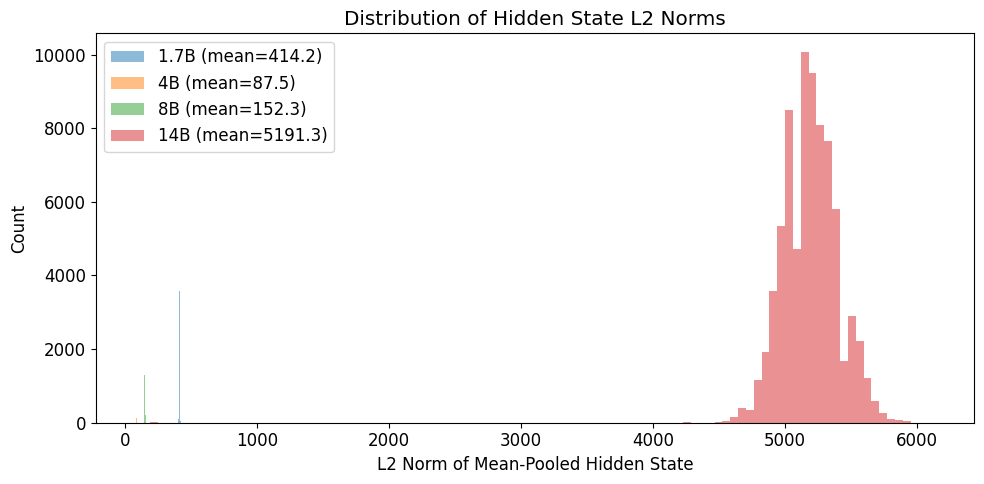

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
for name, hs in pooled_hs.items():
#     if name != "14B":
    norms = hs.norm(dim=1).numpy()
    ax.hist(norms, bins=100, alpha=0.5, label=f"{name} (mean={norms.mean():.1f})")

ax.set_xlabel("L2 Norm of Mean-Pooled Hidden State")
ax.set_ylabel("Count")
ax.set_title("Distribution of Hidden State L2 Norms")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Per-Feature Statistics: Outlier Dimensions

Large LLMs are known to have "outlier features" — a few dimensions with extreme values. These dominate the dot product.

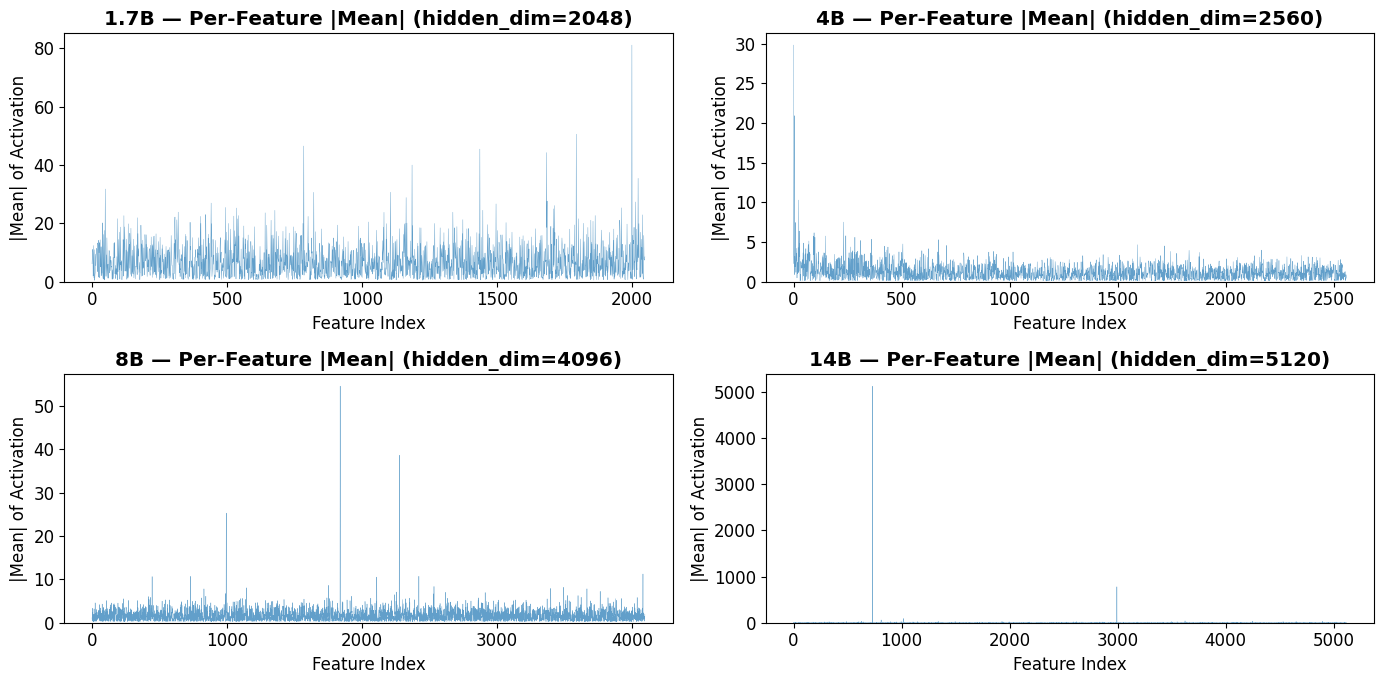

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

for ax, (name, hs) in zip(axes.flat, pooled_hs.items()):
    feat_mean = hs.mean(dim=0).numpy()  # (hidden_dim,)
    feat_std = hs.std(dim=0).numpy()
    feat_abs_mean = hs.abs().mean(dim=0).numpy()

    ax.plot(feat_abs_mean, alpha=0.7, linewidth=0.3)
    ax.set_title(f"{name} — Per-Feature |Mean| (hidden_dim={hs.shape[1]})", fontweight="bold")
    ax.set_xlabel("Feature Index")
    ax.set_ylabel(f"|Mean| of Activation")
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

In [11]:
print("Top-10 features by absolute mean value:")
print("=" * 80)
for name, hs in pooled_hs.items():
    feat_abs_mean = hs.abs().mean(dim=0)
    top_vals, top_idxs = feat_abs_mean.topk(10)
    print(f"\n{name}:")
    for i, (idx, val) in enumerate(zip(top_idxs.tolist(), top_vals.tolist())):
        print(f"  [{i+1}] dim {idx}: |mean|={val:.4f}")

Top-10 features by absolute mean value:

1.7B:
  [1] dim 1999: |mean|=81.0342
  [2] dim 1793: |mean|=50.5372
  [3] dim 784: |mean|=46.4830
  [4] dim 1436: |mean|=45.4313
  [5] dim 1683: |mean|=44.2395
  [6] dim 1185: |mean|=39.9639
  [7] dim 2022: |mean|=35.4179
  [8] dim 49: |mean|=31.7567
  [9] dim 1105: |mean|=30.6687
  [10] dim 821: |mean|=30.6272

4B:
  [1] dim 0: |mean|=29.8234
  [2] dim 4: |mean|=20.9277
  [3] dim 3: |mean|=14.8577
  [4] dim 24: |mean|=10.2980
  [5] dim 232: |mean|=7.5186
  [6] dim 8: |mean|=7.4709
  [7] dim 9: |mean|=6.7539
  [8] dim 26: |mean|=6.3921
  [9] dim 95: |mean|=6.1690
  [10] dim 242: |mean|=5.7889

8B:
  [1] dim 1838: |mean|=54.5518
  [2] dim 2276: |mean|=38.6338
  [3] dim 994: |mean|=25.2756
  [4] dim 4081: |mean|=11.2388
  [5] dim 2421: |mean|=10.7139
  [6] dim 729: |mean|=10.7032
  [7] dim 445: |mean|=10.6321
  [8] dim 2109: |mean|=10.5271
  [9] dim 1750: |mean|=8.6273
  [10] dim 2533: |mean|=8.3559

14B:
  [1] dim 731: |mean|=5123.2104
  [2] dim 

## 5. Simulated Initial Logits

With Xavier uniform init on `Linear(hidden_dim, 1)`, what do the initial logits `z = w·h + b` look like? If `|z|` is huge for 14B, that directly explains the high BCE loss.

In [ ]:
import torch.nn as nn

torch.manual_seed(42)

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)

logit_stats = {}
for ax, (name, hs) in zip(axes, pooled_hs.items()):
    hidden_dim = hs.shape[1]
    linear = nn.Linear(hidden_dim, 1, bias=True)
    nn.init.xavier_uniform_(linear.weight)
    nn.init.zeros_(linear.bias)

    with torch.no_grad():
        logits = linear(hs).squeeze(-1).numpy()

    logit_stats[name] = {
        "mean": logits.mean(),
        "std": logits.std(),
        "abs_mean": np.abs(logits).mean(),
        "max_abs": np.abs(logits).max(),
    }

    ax.hist(logits, bins=100, alpha=0.7)
    ax.set_title(f"{name}\nstd={logits.std():.2f}, max|z|={np.abs(logits).max():.1f}")
    ax.set_xlabel("Logit z = w·h")
    ax.axvline(0, color="red", linestyle="--", alpha=0.5)

plt.suptitle("Distribution of Initial Logits (Xavier Init)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n{'Model':>6} | {'Logit Std':>10} | {'|Logit| Mean':>12} | {'Max |Logit|':>12}")
print("-" * 50)
for name, s in logit_stats.items():
    print(f"{name:>6} | {s['std']:>10.2f} | {s['abs_mean']:>12.2f} | {s['max_abs']:>12.1f}")

## 6. Simulated Initial BCE Loss

Compute what the initial BCE loss would be for each model with Xavier-initialized weights.

In [ ]:
torch.manual_seed(42)

print(f"{'Model':>6} | {'BCE Loss':>12} | {'Logit Std':>12} | {'Hidden Dim':>12} | {'L2 Norm Mean':>14}")
print("-" * 70)

loss_fn = nn.BCEWithLogitsLoss()

for name, hs in pooled_hs.items():
    hidden_dim = hs.shape[1]
    linear = nn.Linear(hidden_dim, 1, bias=True)
    nn.init.xavier_uniform_(linear.weight)
    nn.init.zeros_(linear.bias)

    targets = targets_dict[name]

    with torch.no_grad():
        logits = linear(hs).squeeze(-1)
        bce = loss_fn(logits, targets).item()

    l2 = hs.norm(dim=1).mean().item()
    print(f"{name:>6} | {bce:>12.4f} | {logits.std().item():>12.4f} | {hidden_dim:>12} | {l2:>14.2f}")

## 7. Per-Feature Variance Comparison

Compare the distribution of per-feature variances. If 14B has much higher feature variances, the dot-product output variance scales accordingly.

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for name, hs in pooled_hs.items():
    feat_var = hs.var(dim=0).numpy()
    sorted_var = np.sort(feat_var)[::-1]
    ax.plot(sorted_var, label=f"{name} (sum={feat_var.sum():.1f}, max={feat_var.max():.2f})")

ax.set_xlabel("Feature Rank (sorted by variance)")
ax.set_ylabel("Variance")
ax.set_title("Per-Feature Variance (sorted descending)")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("Sum of per-feature variances (= E[||h - mean(h)||^2]):")
for name, hs in pooled_hs.items():
    feat_var = hs.var(dim=0)
    print(f"  {name}: total_var={feat_var.sum().item():.2f}, mean_var={feat_var.mean().item():.6f}, max_var={feat_var.max().item():.4f}")

## 8. Theoretical Logit Variance

For `z = w·h`, with Xavier init `w_i ~ U[-a, a]` where `a = sqrt(6/(d+1))`, and h_i having variance `σ_i^2` and mean `μ_i`:

$$\text{Var}(z) = \text{Var}(w) \cdot \sum_i (\sigma_i^2 + \mu_i^2) = \frac{2}{d+1} \sum_i (\sigma_i^2 + \mu_i^2)$$

This tells us exactly how much the logit spread depends on the input statistics.

In [ ]:
print(f"{'Model':>6} | {'hidden_dim':>10} | {'Var(w_i)':>10} | {'Σ(σ²+μ²)':>14} | {'Var(z) theory':>14} | {'Std(z) theory':>14}")
print("-" * 80)

for name, hs in pooled_hs.items():
    d = hs.shape[1]
    # Xavier uniform: U[-a, a], variance = a^2/3 = 2/(d+1)
    var_w = 2.0 / (d + 1)

    feat_var = hs.var(dim=0)    # σ_i^2
    feat_mean = hs.mean(dim=0)  # μ_i
    second_moment_sum = (feat_var + feat_mean**2).sum().item()  # Σ(σ² + μ²)

    var_z = var_w * second_moment_sum
    std_z = var_z ** 0.5

    print(f"{name:>6} | {d:>10} | {var_w:>10.6f} | {second_moment_sum:>14.2f} | {var_z:>14.4f} | {std_z:>14.4f}")

## 9. Effect of Z-Score Normalization

If we z-score normalize the hidden states (mean=0, std=1 per feature), all models should have comparable logit magnitudes and BCE loss.

In [ ]:
torch.manual_seed(42)

print(f"{'Model':>6} | {'BCE (raw)':>12} | {'BCE (normed)':>14} | {'Logit Std (raw)':>16} | {'Logit Std (normed)':>20}")
print("-" * 80)

loss_fn = nn.BCEWithLogitsLoss()

for name, hs in pooled_hs.items():
    hidden_dim = hs.shape[1]
    targets = targets_dict[name]

    # Z-score normalize
    mean = hs.mean(dim=0)
    std = hs.std(dim=0) + 1e-8
    hs_normed = (hs - mean) / std

    # Raw
    linear_raw = nn.Linear(hidden_dim, 1, bias=True)
    nn.init.xavier_uniform_(linear_raw.weight)
    nn.init.zeros_(linear_raw.bias)

    # Normed
    linear_norm = nn.Linear(hidden_dim, 1, bias=True)
    nn.init.xavier_uniform_(linear_norm.weight)
    nn.init.zeros_(linear_norm.bias)

    with torch.no_grad():
        logits_raw = linear_raw(hs).squeeze(-1)
        logits_norm = linear_norm(hs_normed).squeeze(-1)
        bce_raw = loss_fn(logits_raw, targets).item()
        bce_norm = loss_fn(logits_norm, targets).item()

    print(f"{name:>6} | {bce_raw:>12.4f} | {bce_norm:>14.4f} | {logits_raw.std().item():>16.4f} | {logits_norm.std().item():>20.4f}")

## 10. Summary

### Root Cause

The 14B model's mean-pooled hidden states have **much larger magnitudes** (L2 norms, per-feature values) compared to smaller models. Without input normalization:

1. The initial logits `z = w·h` have much larger absolute values for 14B
2. `BCEWithLogitsLoss` penalizes large wrong-sign logits severely: when `y ≈ 0` but `z = +100`, loss ≈ 100
3. The same learning rate that works for smaller models may either:
   - Be too large (gradients ∝ hidden state magnitude → divergence)
   - Be too small to recover from the bad initialization (stuck in high-loss region)

### Fixes

1. **Z-score normalization** (`--preprocess`): Standardize hidden states to zero mean, unit variance per feature → all models start with comparable logit magnitudes
2. **Scale learning rate** inversely with hidden state norm: e.g., `lr_14B = lr_8B * (norm_8B / norm_14B)`
3. **Smaller initialization**: Scale Xavier init by `1/||h||` to keep initial logits bounded